##Syllabus Machine Learning II

**Week 11: Association rule learning**

*   Apriori algorithm
*   Eclat algorithm

In [9]:
# Mount Drive files
from google.colab import drive
import sys, os

# Uncomment for mounting drive files
drive.mount('/content/gdrive')

import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning, module='jupyter_client')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [8]:
# We need to install pyECLAT
!pip install pyECLAT

In [10]:
!cp -r "/content/gdrive/MyDrive/Colab Notebooks/Machine Learning II/Week 8/utils.py" /content
!cp -r "/content/gdrive/MyDrive/Colab Notebooks/Machine Learning II/Week 8/data" /content/data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
from matplotlib.patches import Patch
import csv

# Mlxtend library
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules
from mlxtend.preprocessing import TransactionEncoder

# pyECLAT library
from pyECLAT import ECLAT

# sklearn libraries
from sklearn.model_selection import train_test_split

# Utils package
from utils import (
    count_items,
    generate_string_pairs,
    count_tuple_occurrences,
    generate_string_triplets
)

# Matplotlib Options
plt.rcParams['figure.figsize'] = [16, 8]
font = {'weight' : 'bold',
        'size'   : 14}
plt.rc('font', **font)

# Pandas options
pd.set_option("display.max_columns", 100)
pd.set_option('display.max_colwidth', None)

# The Apriori Algorithm - Walkthrough

**Apriori is an algorithm for frequent itemset mining and association rule learning over transactional databases. It is specially used in market basket analysis to create rules based on which items customers buy / order.**
<br>
<br>
It is one of the earliest examples of Recommender Systems.
<br>
<br>
On the downside, the _apriori_ algorithm is computationally expensive for large databases.

As usual, let's start with a simple example - we have 10 users from Netflix that have seen the following shows:

![movies](https://i.ibb.co/TLYgH4y/Presentation1-Unsaved-310130260763099854.jpg)

Let's create this data as a list of lists in `Python`:

In [11]:
list_users_shows = [
    ['Stranger Things', 'Harry Potter and the Sorcerers Stone', 'Harry Potter and the Chamber of Secrets', 'Harry Potter and the Prisoner of Azkaban'],
    ['Stranger Things', 'Harry Potter and the Sorcerers Stone'],
    ['Stranger Things', 'Harry Potter and the Sorcerers Stone'],
    ['Harry Potter and the Sorcerers Stone', 'Harry Potter and the Chamber of Secrets'],
    ['The Witcher', 'The Sandman'],
    ['Stranger Things', 'The Witcher'],
    ['Stranger Things', 'The Witcher'],
    ['Stranger Things', 'Harry Potter and the Chamber of Secrets', 'Harry Potter and the Prisoner of Azkaban'],
    ['The Crown'],
    ['The Crown']
]

The `apriori` algorithm starts by counting the number of times an `item` appears on a specific set:

In [12]:
support = count_items(list_users_shows)

The count we've just done is commonly called `support` of the rule. One of the hyperparameters of the `apriori` algorithm is a minimum frequency(support) we want our items to have. In this case, I'll consider `support=2`, meaning that I'll only want to consider rules that appear at least 2 times on our set of items.
<br>
<br>
*Note: I'm using an integer support just to help with the explanation - in most implementation, support is % of the total item set*

In [13]:
support

{'Stranger Things': 6,
 'Harry Potter and the Sorcerers Stone': 4,
 'Harry Potter and the Chamber of Secrets': 3,
 'Harry Potter and the Prisoner of Azkaban': 2,
 'The Witcher': 3,
 'The Sandman': 1,
 'The Crown': 2}

`The Sandman` is eliminated from our `list_users_show` on the first pass.

In [14]:
for list_shows in list_users_shows:
  if 'The Sandman' in list_shows:
    list_shows.remove('The Sandman')

We can confirm that it was removed by checking the 5th user (index number 4):

In [15]:
list_users_shows[4]

['The Witcher']

Our next set of rules considers only looking at paired rules involving the items that have `support>threshold`. Now, we will pair each item inside the list of lists:

In [16]:
paired_elements = generate_string_pairs(list_users_shows)

In [17]:
paired_elements

[('Stranger Things', 'Harry Potter and the Sorcerers Stone'),
 ('Stranger Things', 'Harry Potter and the Chamber of Secrets'),
 ('Stranger Things', 'Harry Potter and the Prisoner of Azkaban'),
 ('Harry Potter and the Sorcerers Stone',
  'Harry Potter and the Chamber of Secrets'),
 ('Harry Potter and the Sorcerers Stone',
  'Harry Potter and the Prisoner of Azkaban'),
 ('Harry Potter and the Chamber of Secrets',
  'Harry Potter and the Prisoner of Azkaban'),
 ('Stranger Things', 'Harry Potter and the Sorcerers Stone'),
 ('Stranger Things', 'Harry Potter and the Sorcerers Stone'),
 ('Harry Potter and the Sorcerers Stone',
  'Harry Potter and the Chamber of Secrets'),
 ('Stranger Things', 'The Witcher'),
 ('Stranger Things', 'The Witcher'),
 ('Stranger Things', 'Harry Potter and the Chamber of Secrets'),
 ('Stranger Things', 'Harry Potter and the Prisoner of Azkaban'),
 ('Harry Potter and the Chamber of Secrets',
  'Harry Potter and the Prisoner of Azkaban')]

We check the `support` for `n=2`:

In [18]:
support_n2 = count_tuple_occurrences(paired_elements)

In [19]:
support_n2

{('Stranger Things', 'Harry Potter and the Sorcerers Stone'): 3,
 ('Stranger Things', 'Harry Potter and the Chamber of Secrets'): 2,
 ('Stranger Things', 'Harry Potter and the Prisoner of Azkaban'): 2,
 ('Harry Potter and the Sorcerers Stone',
  'Harry Potter and the Chamber of Secrets'): 2,
 ('Harry Potter and the Sorcerers Stone',
  'Harry Potter and the Prisoner of Azkaban'): 1,
 ('Harry Potter and the Chamber of Secrets',
  'Harry Potter and the Prisoner of Azkaban'): 2,
 ('Stranger Things', 'The Witcher'): 2}

From this set of rules, we can create the following rules to test our `confidence` later:

* Who has seen **'Stranger Things'** will want to see **'Harry Potter and the Sorcerers Stone'**.
* Who has seen **'Harry Potter and the Sorcerers Stone'** will want to see **'Stranger Things'**.
* Who has seen **'Stranger Things'** will want to see **'Harry Potter and the Chamber of Secrets'**.
* Who has seen **'Harry Potter and the Chamber of Secrets'** will want to see **'Stranger Things'**.
* Who has seen **'Stranger Things'** will want to see **'Harry Potter and the Prisoner of Azkaban'**.
* Who has seen **'Harry Potter and the Chamber of Secrets'** will want to see **'Stranger Things'**.
* Who has seen **'Harry Potter and the Chamber of Secrets'** will want to see **'Harry Potter and the Sorcerers Stone'**.
* Who has seen **'Harry Potter and the Sorcerers Stone'** will want to see **'Harry Potter and the Chamber of Secrets'**.
* Who has seen **'Harry Potter and the Prisoner of Azkaban'** will want to see **'Harry Potter and the Chamber of Secrets'**.
* Who has seen **'Harry Potter and the Chamber of Secrets'** will want to see **'Harry Potter and the Prisoner of Azkaban'**.
* Who has seen **'The Witcher'** will want to see **'Stranger Things'**.
* Who has seen **'Stranger Things'** will want to see **'The Witcher'**.

To the first item in bold in each statement we call the *antecedent*. To the second item in bold in each statement we call the *consequent*.

Who says that we only want to consider rules with `2` items? The next step is to consider rules with three items, always respecting the minimum `support` value:

In [20]:
triplet_elements = generate_string_triplets(list_users_shows)

In [21]:
triplet_elements

[('Stranger Things',
  'Harry Potter and the Sorcerers Stone',
  'Harry Potter and the Chamber of Secrets'),
 ('Stranger Things',
  'Harry Potter and the Sorcerers Stone',
  'Harry Potter and the Prisoner of Azkaban'),
 ('Stranger Things',
  'Harry Potter and the Chamber of Secrets',
  'Harry Potter and the Prisoner of Azkaban'),
 ('Harry Potter and the Sorcerers Stone',
  'Harry Potter and the Chamber of Secrets',
  'Harry Potter and the Prisoner of Azkaban'),
 ('Stranger Things',
  'Harry Potter and the Chamber of Secrets',
  'Harry Potter and the Prisoner of Azkaban')]

In [22]:
support_n3 = count_tuple_occurrences(triplet_elements)

In [23]:
support_n3

{('Stranger Things',
  'Harry Potter and the Sorcerers Stone',
  'Harry Potter and the Chamber of Secrets'): 1,
 ('Stranger Things',
  'Harry Potter and the Sorcerers Stone',
  'Harry Potter and the Prisoner of Azkaban'): 1,
 ('Stranger Things',
  'Harry Potter and the Chamber of Secrets',
  'Harry Potter and the Prisoner of Azkaban'): 2,
 ('Harry Potter and the Sorcerers Stone',
  'Harry Potter and the Chamber of Secrets',
  'Harry Potter and the Prisoner of Azkaban'): 1}

In this case, only a single triplet pair generates rules - because `Harry Potter Chamber of Secrets`, `Harry Potter and the Prisoner of Azkaban` and `Stranger Things` show up together for two users (**our minimum support**)!
<br>
<br>
The possible rules generated by our triplets are:

*  Who has seen **'Harry Potter Chamber of Secrets'** and **'Harry Potter and the Prisoner of Azkaban'** will want to see **'Stranger Things'**.
*  Who has seen **'Stranger Things'** and **'Harry Potter and the Prisoner of Azkaban'** will want to see **'Harry Potter Chamber of Secrets'**.
*  Who has seen **'Stranger Things'** and **'Harry Potter Chamber of Secrets'** will want to see **'Harry Potter and the Prisoner of Azkaban'**.

Two questions:
* Do we stop our rules on `n=3`?
* Any idea what to do after calculating the rules?

![discuss](https://cdn-icons-png.flaticon.com/512/1189/1189168.png)

Our `support` takes into account common probability - we check the probability of an item (or group of items) appearing in the set. In our example, we've checked items or group of items that showed up in at least **20% of our users'  view list**.

But what if these items just show up together because they are super frequent? What if the rules that we are just creating just show up because of the popularity of the shows?
<br>
<br>
That's where the conditional probability part (`confidence`) of the `apriori` algorithm will help - let's pick up one of the rules of the examples above - for example:
*  Who has seen **'Harry Potter and the Sorcerers Stone'** will want to see **'Stranger Things'**.

Calculating confidence is easy - to generalize our rules a bit better, let's call `Harry Potter and the Sorcerers Stone` the `itemA` and `Stranger Things` as `itemB`.
<br>
<br>
The formula for `confidence` is:

$$confidence(A \rightarrow B) = \frac{support(A \cap B)}{support(A)}$$

Let's see our users view list again:

![movies](https://i.ibb.co/TLYgH4y/Presentation1-Unsaved-310130260763099854.jpg)

How many times do `itemA` and `itemB`show up together? 3 times, the first 3 users!
<br>
<br>
And how many times does `itemA` show up? 4 times!
<br>
<br>
Our confidence in this rule is `0.75`. The higher the confidence, the higher we are sure that someone that has seen `Harry Potter and the Sorcerers Stone` will want to see `Stranger Things`. In our case, we are 75% certain that this rule will stand.

What if the rule has more items? Let's see an example:
*  Who has seen *'Stranger Things' (itemA)* and *'Harry Potter Chamber of Secrets'(itemB)* will want to see *'Harry Potter and the Prisoner of Azkaban'(itemC)*.

Formula for confidence of this rule is:

$$confidence(A \cup B \rightarrow C) = \frac{support(A \cap B \cap C)}{support(A \cap B)}$$

With our items, we have:
$$confidence(A \cup B \rightarrow C) = \frac{2}{2} = 1$$

`confidence` of 1 as every time item A and B show up, C will also show up.

One last useful metric to calculate, the `lift`. Lift is calculated with the following formula:
$$lift(A \rightarrow B) = \frac{support(A \cap B)}{support(A) \cdot support(B)}$$

Lift measures the dependency of the items. For example - let's test some random lifts:

In [24]:
# if the items always co-ocurr, lift will be high and over 1
0.03 / (0.03*0.03)

33.333333333333336

In [25]:
# If the items co ocurr with one of the items appearing on many other
# transactions, lift will be lower
0.2 / (0.2*0.8)

1.2499999999999998

In [26]:
# If the items co ocurr and both items appear frequently on other
# transactions, lift is really low
0.2 / (0.8*0.8)

0.31249999999999994

To use `apriori` inside `Python`, we can use the `mlxtend` package:

In [27]:
# First we need to put our data in Transaction Encoder format
te = TransactionEncoder()
te_fit = te.fit(list_users_shows).transform(list_users_shows)
users_x_tvshows = pd.DataFrame(te_fit, columns=te.columns_)

In [28]:
users_x_tvshows

,Harry Potter and the Chamber of Secrets,Harry Potter and the Prisoner of Azkaban,Harry Potter and the Sorcerers Stone,Stranger Things,The Crown,The Witcher
0,True,True,True,True,False,False
1,False,False,True,True,False,False
2,False,False,True,True,False,False
3,True,False,True,False,False,False
4,False,False,False,False,False,True
5,False,False,False,True,False,True
6,False,False,False,True,False,True
7,True,True,False,True,False,False
8,False,False,False,False,True,False
9,False,False,False,False,True,False


Now, we can run our `apriori` algorithm. We're going to use `min_support=0.2` to mimic our example.

In [29]:
frequent_itemsets = apriori(users_x_tvshows, min_support=0.2, use_colnames=True)

The `frequent_itemsets` object contains the minimum support tuples, just like we've done on our example:

In [30]:
frequent_itemsets

,support,itemsets
0,0.3,(Harry Potter and the Chamber of Secrets)
1,0.2,(Harry Potter and the Prisoner of Azkaban)
2,0.4,(Harry Potter and the Sorcerers Stone)
3,0.6,(Stranger Things)
4,0.2,(The Crown)
5,0.3,(The Witcher)
6,0.2,"(Harry Potter and the Prisoner of Azkaban, Harry Potter and the Chamber of Secrets)"
7,0.2,"(Harry Potter and the Chamber of Secrets, Harry Potter and the Sorcerers Stone)"
8,0.2,"(Harry Potter and the Chamber of Secrets, Stranger Things)"
9,0.2,"(Harry Potter and the Prisoner of Azkaban, Stranger Things)"


We can generate the rules based on this itemset by passing our object into the `association_rules` function. Here, we're going to use a minimum `confidence` of 60% to view our rules.

In [31]:

rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.6)

In [32]:
rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(Harry Potter and the Prisoner of Azkaban),(Harry Potter and the Chamber of Secrets),0.2,0.3,0.2,1.000000,3.333333,1.0,0.14,inf,0.875000,0.666667,1.000000,0.833333
1,(Harry Potter and the Chamber of Secrets),(Harry Potter and the Prisoner of Azkaban),0.3,0.2,0.2,0.666667,3.333333,1.0,0.14,2.4,1.000000,0.666667,0.583333,0.833333
2,(Harry Potter and the Chamber of Secrets),(Harry Potter and the Sorcerers Stone),0.3,0.4,0.2,0.666667,1.666667,1.0,0.08,1.8,0.571429,0.400000,0.444444,0.583333
3,(Harry Potter and the Chamber of Secrets),(Stranger Things),0.3,0.6,0.2,0.666667,1.111111,1.0,0.02,1.2,0.142857,0.285714,0.166667,0.500000
4,(Harry Potter and the Prisoner of Azkaban),(Stranger Things),0.2,0.6,0.2,1.000000,1.666667,1.0,0.08,inf,0.500000,0.333333,1.000000,0.666667
5,(Harry Potter and the Sorcerers Stone),(Stranger Things),0.4,0.6,0.3,0.750000,1.250000,1.0,0.06,1.6,0.333333,0.428571,0.375000,0.625000
6,(The Witcher),(Stranger Things),0.3,0.6,0.2,0.666667,1.111111,1.0,0.02,1.2,0.142857,0.285714,0.166667,0.500000
7,"(Harry Potter and the Prisoner of Azkaban, Harry Potter and the Chamber of Secrets)",(Stranger Things),0.2,0.6,0.2,1.000000,1.666667,1.0,0.08,inf,0.500000,0.333333,1.000000,0.666667
8,"(Harry Potter and the Prisoner of Azkaban, Stranger Things)",(Harry Potter and the Chamber of Secrets),0.2,0.3,0.2,1.000000,3.333333,1.0,0.14,inf,0.875000,0.666667,1.000000,0.833333
9,"(Harry Potter and the Chamber of Secrets, Stranger Things)",(Harry Potter and the Prisoner of Azkaban),0.2,0.2,0.2,1.000000,5.000000,1.0,0.16,inf,1.000000,1.000000,1.000000,1.000000


Let's compare our rules with our users preference:

![movies](https://i.ibb.co/TLYgH4y/Presentation1-Unsaved-310130260763099854.jpg)

Now, we have things to recommend to our users - for example, everytime a new user watches `Harry Potter and the Sorcerers Stone`, we can recommend them `Stranger Things`.

Some downsides and limitations of the algorithm:
* It is computationally expensive (really expensive!).
* It doesn't consider any relationship between the items. For example, we know that `Harry Potter and the Chamber of Secrets` follows `Harry Potter and the Sorcerer's Stone` but, if by random chance, our users didn't watch both on the platform, we would have trouble recommending `Chamber of Secrets`.
* It tends to show up rules with a lot of frequent items (due to `min_support` parameter).

Next, let's see another algorithm called `eclat` that is very similar to the one we've seen above!

# Eclat Algorithm - Walkthrough

Although very similar to `apriori` algorithm, `eclat` speeds things up by looking at fewer metrics, namely `confidence`, although this property only shows up in datasets that are very large and sparse. **This is not always the case and Eclat may be slower in certain datasets.**
<br>
In a way, `eclat` shows rules as `apriori` - in our case, they will be exactly the same but that is not always what happens.
<br>
Let's start again from scratch, using our users' view list:

In [33]:
list_users_shows = [
    ['Stranger Things', 'Harry Potter and the Sorcerers Stone', 'Harry Potter and the Chamber of Secrets', 'Harry Potter and the Prisoner of Azkaban'],
    ['Stranger Things', 'Harry Potter and the Sorcerers Stone'],
    ['Stranger Things', 'Harry Potter and the Sorcerers Stone'],
    ['Harry Potter and the Sorcerers Stone', 'Harry Potter and the Chamber of Secrets'],
    ['The Witcher', 'The Sandman'],
    ['Stranger Things', 'The Witcher'],
    ['Stranger Things', 'The Witcher'],
    ['Stranger Things', 'Harry Potter and the Chamber of Secrets', 'Harry Potter and the Prisoner of Azkaban'],
    ['The Crown'],
    ['The Crown']
]

`eclat` starts differently, it creates a table that maps each item to a "transaction". In our case, "transaction" is represented by "users":

In [34]:
eclat_map = {}

for index, user in enumerate(list_users_shows):
  for show in user:
    if show in eclat_map.keys():
      eclat_map[show].append('User'+str(index))
    else:
      eclat_map[show] = ['User'+str(index)]


In [35]:
eclat_map

{'Stranger Things': ['User0', 'User1', 'User2', 'User5', 'User6', 'User7'],
 'Harry Potter and the Sorcerers Stone': ['User0', 'User1', 'User2', 'User3'],
 'Harry Potter and the Chamber of Secrets': ['User0', 'User3', 'User7'],
 'Harry Potter and the Prisoner of Azkaban': ['User0', 'User7'],
 'The Witcher': ['User4', 'User5', 'User6'],
 'The Sandman': ['User4'],
 'The Crown': ['User8', 'User9']}

The `eclat` support, starts by checking which items appear in at least `k` transactions. This step is equivalent to `apriori`.
<br>
<br>
Let's remove `The Sandman`:

In [36]:
del eclat_map['The Sandman']

In [37]:
eclat_map

{'Stranger Things': ['User0', 'User1', 'User2', 'User5', 'User6', 'User7'],
 'Harry Potter and the Sorcerers Stone': ['User0', 'User1', 'User2', 'User3'],
 'Harry Potter and the Chamber of Secrets': ['User0', 'User3', 'User7'],
 'Harry Potter and the Prisoner of Azkaban': ['User0', 'User7'],
 'The Witcher': ['User4', 'User5', 'User6'],
 'The Crown': ['User8', 'User9']}

Now, we create a dictionary with all combinations of the items that passed the first `support` filter:

In [38]:
eclat_map_n1 = {
  ('Stranger Things', 'Harry Potter and the Sorcerers Stone'): 3,
  ('Stranger Things', ' Harry Potter and the Chamber of Secrets'): 2,
  ('Stranger Things', 'Harry Potter and the Prisoner of Azkaban'): 2,
  ('Stranger Things', 'The Witcher'): 2,
  ('Stranger Things', 'The Crown'): 0,
  ('Harry Potter and the Sorcerers Stone', ' Harry Potter and the Chamber of Secrets'): 2,
  ('Harry Potter and the Sorcerers Stone', 'Harry Potter and the Prisoner of Azkaban'): 2,
  ('Harry Potter and the Sorcerers Stone', 'The Witcher'): 0,
  ('Harry Potter and the Sorcerers Stone', 'The Crown'): 0,
  ('Harry Potter and the Chamber of Secrets', 'Harry Potter and the Prisoner of Azkaban'): 2,
  ('Harry Potter and the Chamber of Secrets', 'The Witcher'): 0,
  ('Harry Potter and the Chamber of Secrets', 'The Crown'): 0,
  ('Harry Potter and the Prisoner of Azkaban', 'The Witcher'): 0,
  ('Harry Potter and the Prisoner of Azkaban', 'The Crown'): 0,
  ('The Witcher', 'The Crown'): 0
}

What combinations are carried forward?

In [39]:
pd.DataFrame(
    [eclat_map_n1]
).T.sort_values(by=0, ascending=False)

,0
"(Stranger Things, Harry Potter and the Sorcerers Stone)",3
"(Stranger Things, Harry Potter and the Chamber of Secrets)",2
"(Stranger Things, Harry Potter and the Prisoner of Azkaban)",2
"(Stranger Things, The Witcher)",2
"(Harry Potter and the Sorcerers Stone, Harry Potter and the Chamber of Secrets)",2
"(Harry Potter and the Sorcerers Stone, Harry Potter and the Prisoner of Azkaban)",2
"(Harry Potter and the Chamber of Secrets, Harry Potter and the Prisoner of Azkaban)",2
"(Stranger Things, The Crown)",0
"(Harry Potter and the Sorcerers Stone, The Witcher)",0
"(Harry Potter and the Sorcerers Stone, The Crown)",0


Only those with `support >= 2` - in this case:
* (Stranger Things, Harry Potter and the Sorcerers Stone):	3
* (Harry Potter and the Sorcerers Stone, Harry Potter and the Chamber of Secrets): 2
* (Stranger Things, Harry Potter and the Chamber of Secrets):	2
* (Stranger Things, Harry Potter and the Prisoner of Azkaban):	2
* (Stranger Things, The Witcher):	2
* (Harry Potter and the Sorcerers Stone, Harry Potter and the Prisoner of Azkaban):	2
* (Harry Potter and the Chamber of Secrets, Harry Potter and the Prisoner of Azkaban): 2

Finally, we can pick up the 4 movies that we see above and generate the `triplets` based on them:

In [40]:
eclat_map_n2 = {
  ('Stranger Things', 'Harry Potter and the Sorcerers Stone', ' Harry Potter and the Chamber of Secrets'): 1,
  ('Stranger Things', ' Harry Potter and the Sorcerers Stone', ' Harry Potter and the Prisoner of Azkaban'): 1,
  ('Stranger Things', ' Harry Potter and the Sorcerers Stone', 'The Witcher'): 0,
  ('Stranger Things', ' Harry Potter and the Chamber of Secrets', ' Harry Potter and the Prisoner of Azkaban'): 2,
  ('Stranger Things', ' Harry Potter and the Chamber of Secrets', 'The Witcher'): 0,
  ('Stranger Things', ' Harry Potter and the Prisoner of Azkaban', 'The Witcher'): 0,
  ('Harry Potter and the Sorcerers Stone', ' Harry Potter and the Chamber of Secrets', ' Harry Potter and the Prisoner of Azkaban'): 1,
  ('Harry Potter and the Sorcerers Stone', ' Harry Potter and the Chamber of Secrets', 'The Witcher'): 0,
  ('Harry Potter and the Sorcerers Stone', ' Harry Potter and the Prisoner of Azkaban', 'The Witcher'): 0,
  ('Harry Potter and the Chamber of Secrets', ' Harry Potter and the Prisoner of Azkaban', 'The Witcher'): 0
}

In [41]:
pd.DataFrame(
    [eclat_map_n2]
).T.sort_values(by=0, ascending=False)

,0
"(Stranger Things, Harry Potter and the Chamber of Secrets, Harry Potter and the Prisoner of Azkaban)",2
"(Stranger Things, Harry Potter and the Sorcerers Stone, Harry Potter and the Chamber of Secrets)",1
"(Stranger Things, Harry Potter and the Sorcerers Stone, Harry Potter and the Prisoner of Azkaban)",1
"(Harry Potter and the Sorcerers Stone, Harry Potter and the Chamber of Secrets, Harry Potter and the Prisoner of Azkaban)",1
"(Stranger Things, Harry Potter and the Chamber of Secrets, The Witcher)",0
"(Stranger Things, Harry Potter and the Sorcerers Stone, The Witcher)",0
"(Stranger Things, Harry Potter and the Prisoner of Azkaban, The Witcher)",0
"(Harry Potter and the Sorcerers Stone, Harry Potter and the Chamber of Secrets, The Witcher)",0
"(Harry Potter and the Sorcerers Stone, Harry Potter and the Prisoner of Azkaban, The Witcher)",0
"(Harry Potter and the Chamber of Secrets, Harry Potter and the Prisoner of Azkaban, The Witcher)",0


Only one rule is going forward!
* (Stranger Things, Harry Potter and the Chamber of Secrets, Harry Potter and the Prisoner of Azkaban)

Due to its nature (and as the algorithm doesn't try to calculate `lift` or `confidence`), there's no `antecedents` and `consequents` - the rules are basically the association between items and have a specific support:

In [42]:
eclat_rules = {
    ('Stranger Things', 'Harry Potter and the Chamber of Secrets', ' Harry Potter and the Prisoner of Azkaban'): 2/len(list_users_shows),
    ('Stranger Things', 'Harry Potter and the Sorcerers Stone'): 3/len(list_users_shows),
    ('Harry Potter the Sorcerers Stone', 'Harry Potter and the Chamber of Secrets'): 2/len(list_users_shows),
    ('Stranger Things', 'Harry Potter and the Chamber of Secrets'): 2/len(list_users_shows),
    ('Stranger Things', 'Harry Potter and the Prisoner of Azkaban'): 2/len(list_users_shows),
    ('Stranger Things', 'The Witcher'): 2/len(list_users_shows),
    ('Harry Potter and the Sorcerers Stone', 'Harry Potter and the Prisoner of Azkaban'): 2/len(list_users_shows),
    ('Harry Potter the Chamber of Secrets', 'Harry Potter and the Prisoner of Azkaban'):2/len(list_users_shows)
}

And finally, seeing our rules:

In [43]:
pd.DataFrame(
    [eclat_rules]
).T.sort_values(by=0, ascending=False)

,0
"(Stranger Things, Harry Potter and the Sorcerers Stone)",0.3
"(Stranger Things, Harry Potter and the Chamber of Secrets, Harry Potter and the Prisoner of Azkaban)",0.2
"(Harry Potter the Sorcerers Stone, Harry Potter and the Chamber of Secrets)",0.2
"(Stranger Things, Harry Potter and the Chamber of Secrets)",0.2
"(Stranger Things, Harry Potter and the Prisoner of Azkaban)",0.2
"(Stranger Things, The Witcher)",0.2
"(Harry Potter and the Sorcerers Stone, Harry Potter and the Prisoner of Azkaban)",0.2
"(Harry Potter the Chamber of Secrets, Harry Potter and the Prisoner of Azkaban)",0.2


The `ECLAT` function from `pyeclat` helps us to build association rules based on the `eclat` algorithm:

In [44]:
my_eclat = ECLAT(data=pd.DataFrame(list_users_shows))

In [45]:
# eclat uses an api similar to sklearn. Let's use our min_support of 20%
rule_indices, rule_supports = my_eclat.fit(min_support=0.2,
                                           min_combination=2,
                                           max_combination=3)

Combination 2 by 2


15it [00:00, 176.12it/s]


Combination 3 by 3


20it [00:00, 243.73it/s]


In [46]:
# And seeing how our rules match what we've done!

rules_eclat = pd.DataFrame(
  list(rule_supports.values()),
  index=list(rule_supports.keys()),
  columns=['support']
)

rules_eclat.sort_values(by='support', ascending=False)

,support
Harry Potter and the Sorcerers Stone & Stranger Things,0.3
Harry Potter and the Prisoner of Azkaban & Stranger Things,0.2
Harry Potter and the Prisoner of Azkaban & Harry Potter and the Chamber of Secrets,0.2
Harry Potter and the Chamber of Secrets & Harry Potter and the Sorcerers Stone,0.2
Harry Potter and the Chamber of Secrets & Stranger Things,0.2
The Witcher & Stranger Things,0.2
Harry Potter and the Prisoner of Azkaban & Harry Potter and the Chamber of Secrets & Stranger Things,0.2


*Reminder: the rules are the same as our apriori because of the characteristics of our dataset.

# Practical Example - Obtaining Association Rules from a Grocery Store

Dataset:https://www.kaggle.com/datasets/d4rklucif3r/market-basket-optimisation
<br>
<br>

In this example, we are going to explore a couple of rules using data from a retail store (this will aim to emulate something similar to what you will do in the practical project). Let's start by loading our transactions using the `csv` module:

In [47]:
with open('/content/data/market_basket_sample.csv', 'r') as file:
  reader = csv.reader(file)
  reader = list(reader)


Here are the first `10` transactions of our dataset:

In [48]:
reader[0:10]

[['shrimp',
  'almonds',
  'avocado',
  'vegetables mix',
  'green grapes',
  'whole weat flour',
  'yams',
  'cottage cheese',
  'energy drink',
  'tomato juice',
  'low fat yogurt',
  'green tea',
  'honey',
  'salad',
  'mineral water',
  'salmon',
  'antioxydant juice',
  'frozen smoothie',
  'spinach',
  'olive oil'],
 ['burgers', 'meatballs', 'eggs'],
 ['chutney'],
 ['turkey', 'avocado'],
 ['mineral water', 'milk', 'energy bar', 'whole wheat rice', 'green tea'],
 ['low fat yogurt'],
 ['whole wheat pasta', 'french fries'],
 ['soup', 'light cream', 'shallot'],
 ['frozen vegetables', 'spaghetti', 'green tea'],
 ['french fries']]

In market basket analysis, it may be a good idea to split the data into train and test, and check if the rules that we are running in a part of the dataset generalize for the other dataset - this is not mandatory, though. Let's split our list into two groups:

In [49]:
train = reader[:int(len(reader)*0.8)]
test = reader[int(len(reader)*0.8):]

In [50]:
print('We have {} rows in the train set.'.format(len(train)))
print('We have {} rows in the test set.'.format(len(test)))

We have 6000 rows in the train set.
We have 1501 rows in the test set.


Let's run some `apriori` rules in our `train` dataframe (but first, encoding our data):

In [51]:
te = TransactionEncoder()
te_fit = te.fit(train).transform(train)
transactions_items = pd.DataFrame(te_fit, columns=te.columns_)

In [52]:
# Viewing our transactions_items
transactions_items.head(10)

,asparagus,almonds,antioxydant juice,asparagus,avocado,babies food,bacon,barbecue sauce,black tea,blueberries,body spray,bramble,brownies,bug spray,burger sauce,burgers,butter,cake,candy bars,carrots,cauliflower,cereals,champagne,chicken,chili,chocolate,chocolate bread,chutney,cider,clothes accessories,cookies,cooking oil,corn,cottage cheese,cream,dessert wine,eggplant,eggs,energy bar,energy drink,escalope,extra dark chocolate,flax seed,french fries,french wine,fresh bread,fresh tuna,fromage blanc,frozen smoothie,frozen vegetables,...,melons,milk,mineral water,mint,mint green tea,muffins,mushroom cream sauce,napkins,nonfat milk,oatmeal,oil,olive oil,pancakes,parmesan cheese,pasta,pepper,pet food,pickles,protein bar,red wine,rice,salad,salmon,salt,sandwich,shallot,shampoo,shrimp,soda,soup,spaghetti,sparkling water,spinach,strawberries,strong cheese,tea,tomato juice,tomato sauce,tomatoes,toothpaste,turkey,vegetables mix,water spray,white wine,whole weat flour,whole wheat pasta,whole wheat rice,yams,yogurt cake,zucchini
0,False,True,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,...,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,True,False,False,False,False,True,False,False,False,True,False,False,False,False,True,False,False,True,False,False,True,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,...,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,Fal

Now, we can pass our data to the `apriori` algorithm:

In [53]:
# Using 5% as minimum support and obtaining frequent_itemsets_grocery
# In real life scenario, support is typically a value between 3% to 8%, depending
# on the dataset
frequent_itemsets_grocery = apriori(
    transactions_items, min_support=0.05, use_colnames=True
    )

In [54]:
frequent_itemsets_grocery.sort_values(by='support', ascending=False)

,support,itemsets
17,0.241667,(mineral water)
21,0.184000,(spaghetti)
6,0.178833,(eggs)
8,0.175833,(french fries)
3,0.167500,(chocolate)
12,0.134167,(green tea)
16,0.129833,(milk)
13,0.100500,(ground beef)
10,0.095833,(frozen vegetables)
19,0.094500,(pancakes)


We see that `Mineral Water` is present on the basket of 25% of our customer base. There are a couple of paired itemsets, such as `Mineral Water` and `Spaghetti` - let's produce rules based on these pairs and see the result:

In [55]:
# We'll use a confidence level of 20%
rules_grocery = association_rules(frequent_itemsets_grocery,
                                  metric="confidence",
                                  min_threshold=0.2)

In [56]:
rules_grocery

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(chocolate),(mineral water),0.167500,0.241667,0.055500,0.331343,1.371076,1.0,0.015021,1.134115,0.325100,0.156927,0.118255,0.280499
1,(mineral water),(chocolate),0.241667,0.167500,0.055500,0.229655,1.371076,1.0,0.015021,1.080685,0.356895,0.156927,0.074661,0.280499
2,(mineral water),(eggs),0.241667,0.178833,0.052167,0.215862,1.207057,1.0,0.008949,1.047222,0.226205,0.141629,0.045093,0.253784
3,(eggs),(mineral water),0.178833,0.241667,0.052167,0.291705,1.207057,1.0,0.008949,1.070647,0.208897,0.141629,0.065985,0.253784
4,(spaghetti),(mineral water),0.184000,0.241667,0.063500,0.345109,1.428036,1.0,0.019033,1.157953,0.367325,0.175334,0.136407,0.303934
5,(mineral water),(spaghetti),0.241667,0.184000,0.063500,0.262759,1.428036,1.0,0.019033,1.106829,0.395258,0.175334,0.096518,0.303934


Some interesting rules here - but these rules tend to encapsulate the most popular items (lift is kind-of low..). Any idea of how we can improve this?

![discuss](https://cdn-icons-png.flaticon.com/512/1189/1189168.png)

**Lower support!**

In [57]:
frequent_itemsets_grocery_iter_2 = apriori(
    transactions_items, min_support=0.02, use_colnames=True
    )

# We'll use a confidence level of 20%
rules_grocery_iter_2 = association_rules(frequent_itemsets_grocery_iter_2,
                                  metric="confidence",
                                  min_threshold=0.2)

In [58]:
rules_grocery_iter_2.sort_values(by='lift', ascending=False).head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
40,(spaghetti),(ground beef),0.184000,0.100500,0.042500,0.230978,2.298291,1.0,0.024008,1.169668,0.692272,0.175620,0.145056,0.326932
41,(ground beef),(spaghetti),0.100500,0.184000,0.042500,0.422886,2.298291,1.0,0.024008,1.413931,0.628009,0.175620,0.292752,0.326932
33,(frozen vegetables),(milk),0.095833,0.129833,0.025167,0.262609,2.022660,1.0,0.012724,1.180061,0.559191,0.125520,0.152586,0.228223
50,(soup),(mineral water),0.049833,0.241667,0.023500,0.471572,1.951332,1.0,0.011457,1.435074,0.513099,0.087687,0.303172,0.284407
55,(olive oil),(spaghetti),0.068833,0.184000,0.024500,0.355932,1.934414,1.0,0.011835,1.266947,0.518755,0.107299,0.210701,0.244542
30,(turkey),(eggs),0.063000,0.178833,0.020833,0.330688,1.849140,1.0,0.009567,1.226881,0.490083,0.094268,0.184925,0.223592
47,(olive oil),(mineral water),0.068833,0.241667,0.029333,0.426150,1.763380,1.0,0.012699,1.321484,0.464908,0.104327,0.243275,0.273765
35,(frozen vegetables),(spaghetti),0.095833,0.184000,0.031000,0.323478,1.758034,1.0,0.013367,1.206170,0.476884,0.124581,0.170929,0.245978
38,(ground beef),(milk),0.100500,0.129833,0.022833,0.227197,1.749915,1.0,0.009785,1.125988,0.476424,0.110040,0.111891,0.201532
39,(ground beef),(mineral water),0.100500,0.241667,0.042167,0.419569,1.736147,1.0,0.017879,1.306500,0.471386,0.140556,0.234596,0.297026


Interesting! Now we are able to get items that are probably bought together more often, not because they are popular, but because customers may be looking for them to follow some recipe.
<br>
<br>
For example, `Spaghetti` and `Ground beef` being bought together make a lot of sense.

How can we evaluate if this generalizes? One idea is to check the stability of the `lift` metric. For example, generating these rules for the test set, and comparing lifts between both solutions:

In [59]:
train_data_rules = rules_grocery_iter_2[['antecedents','consequents','lift']]

In [60]:
te = TransactionEncoder()
te_fit_test = te.fit(test).transform(test)
transactions_items_test = pd.DataFrame(te_fit_test, columns=te.columns_)

frequent_itemsets_test = apriori(
    transactions_items_test, min_support=0.02, use_colnames=True
    )

# We'll use a confidence level of 20%
rules_grocery_test = association_rules(frequent_itemsets_test,
                                  metric="confidence",
                                  min_threshold=0.2)

In [61]:
test_data_rules = rules_grocery_test[['antecedents','consequents','lift']]
test_data_rules.columns = ['antecedents','consequents','lift_test']

In [62]:
evaluation = train_data_rules.merge(
    test_data_rules,
    on=['antecedents','consequents']
)

Let's see the lift for the same rules between the training data and the test data:

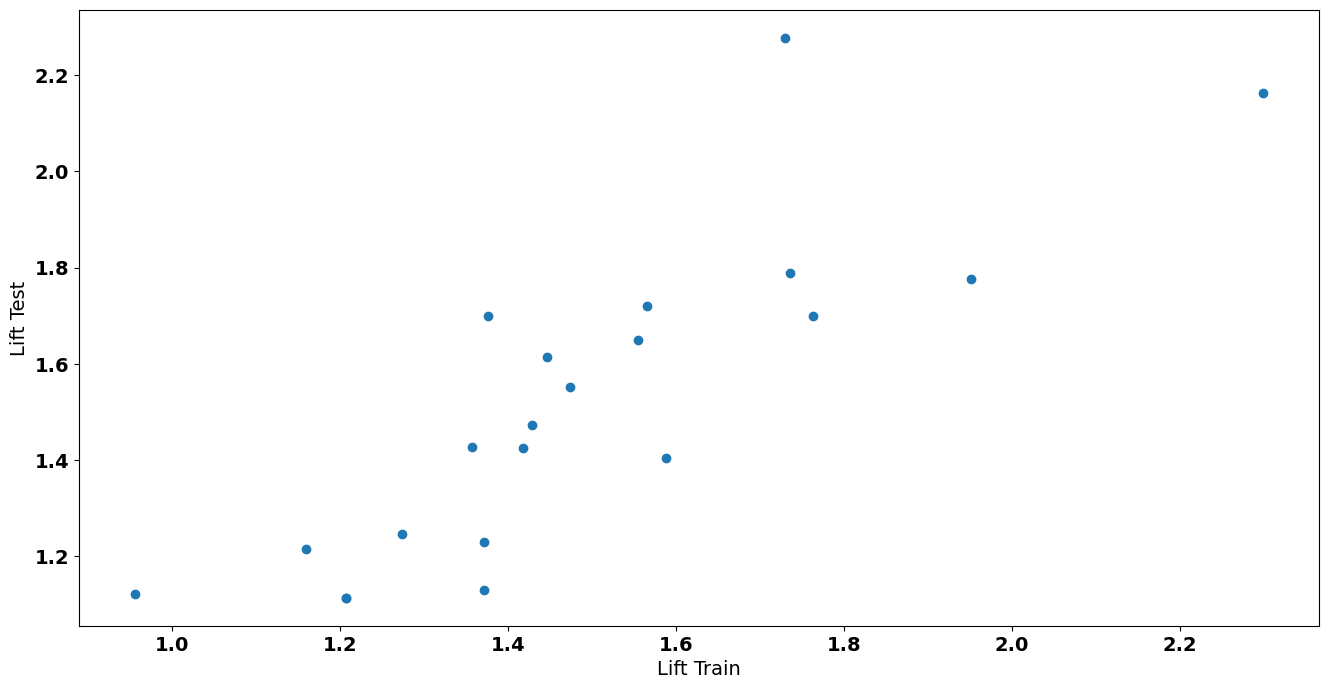

In [63]:
plt.scatter(
    evaluation.lift,
    evaluation.lift_test
)

plt.xlabel('Lift Train')
plt.ylabel('Lift Test')
plt.show()

Ideally, this `test` data is obtained in a different moment of the `train` - for example, more recent transactions.

We can calculate the % absolute difference between the values to have a metric on how well our train and test scenarios approximate:

In [64]:
(np.abs(evaluation.lift-evaluation.lift_test)/evaluation.lift).mean()

np.float64(0.09408853882845712)

For us to compare with `eclat`, let's see the top rules by `support` produced by our `apriori` algorithm:

In [65]:
rules_grocery_iter_2.sort_values(by='support', ascending=False).head(20)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
51,(spaghetti),(mineral water),0.184000,0.241667,0.063500,0.345109,1.428036,1.0,0.019033,1.157953,0.367325,0.175334,0.136407,0.303934
52,(mineral water),(spaghetti),0.241667,0.184000,0.063500,0.262759,1.428036,1.0,0.019033,1.106829,0.395258,0.175334,0.096518,0.303934
14,(chocolate),(mineral water),0.167500,0.241667,0.055500,0.331343,1.371076,1.0,0.015021,1.134115,0.325100,0.156927,0.118255,0.280499
15,(mineral water),(chocolate),0.241667,0.167500,0.055500,0.229655,1.371076,1.0,0.015021,1.080685,0.356895,0.156927,0.074661,0.280499
26,(eggs),(mineral water),0.178833,0.241667,0.052167,0.291705,1.207057,1.0,0.008949,1.070647,0.208897,0.141629,0.065985,0.253784
25,(mineral water),(eggs),0.241667,0.178833,0.052167,0.215862,1.207057,1.0,0.008949,1.047222,0.226205,0.141629,0.045093,0.253784
44,(mineral water),(milk),0.241667,0.129833,0.049833,0.206207,1.588243,1.0,0.018457,1.096213,0.488405,0.154922,0.087769,0.295016
43,(milk),(mineral water),0.129833,0.241667,0.049833,0.383825,1.588243,1.0,0.018457,1.230712,0.425635,0.154922,0.187462,0.295016
40,(spaghetti),(ground beef),0.184000,0.100500,0.042500,0.230978,2.298291,1.0,0.024008,1.169668,0.692272,0.175620,0.145056,0.326932
41,(ground beef),(spaghetti),0.100500,0.184000,0.042500,0.422886,2.298291,1.0,0.024008,1.413931,0.628009,0.175620,0.292752,0.326932


And now building the rules using `ECLAT`:

In [66]:
eclat_groceries = ECLAT(data=pd.DataFrame(train))

In [ ]:
groceries_rules_indexes, groceries_rules_supports = eclat_groceries.fit(min_support=0.02,
                                           min_combination=2,
                                           max_combination=2)

Combination 2 by 2


1020it [00:28, 20.52it/s]

In [ ]:
rules_eclat_groceries = pd.DataFrame(
  list(groceries_rules_supports.values()),
  index=list(groceries_rules_supports.keys()),
  columns=['support']
)

rules_eclat_groceries.sort_values(by='support', ascending=False).head(10)

# Exercise Section!

As usual, let's do some exercises on the algorithms we've just learned!

### Exercise 1

Load the `tv_shows.csv` file into a list using the `csv` module. Save the read file as an object named `tvshows`.
<br>
<br>
Hint: Your returning object should be a list of lists!

In [ ]:
### YOUR CODE HERE

### Exercise 2

If you have blank items in the lists inside `tvshows` list, remove all the empty items from the sublists. Save the new list without empty items in the same object.

In [ ]:
### YOUR CODE HERE

### Exercise 3

Split the `tvshows` lists into `train_tvshows` and `test_tvshows`. Allocate 70% of the `tvshows` to the `train_tvshows` list.

In [ ]:
### YOUR CODE HERE

### Exercise 4

Convert `train_tvshows` to sparse format by using `TransactionEncoder` (matrix format with `True` and `False`).
<br>
<br>
Save the sparse matrix in an object named `sparse_tvshows`.

In [ ]:
### YOUR CODE HERE

### Exercise 5

Train an `apriori` algorithm on the `sparse_tvshows` data with 0.02 minimum support. Name the returning object `apriori_tvshows`.
<br>
<br>
*Hint: You may want to use the arguments `use_colnames=True` as well!*

In [ ]:
### YOUR CODE HERE

### Exercise 6

Obtain the rules based on our `apriori_tvshows` with a lift over 2. Save the returning element in an object named `top_lift`.

In [ ]:
### YOUR CODE HERE

### Exercise 7

Which rule has the most lift?

In [ ]:
### YOUR CODE HERE

### Exercise 8

Which rule has the most support?

In [ ]:
### YOUR CODE HERE

### Exercise 9

What is the absolute mean difference between the lifts obtained on the training set and the test set?
<br>
<br>
*Hint: Use the code that we've used during the class!*

In [ ]:
### YOUR CODE HERE